In [2]:
import os
import dotenv
import docx
import pdfplumber
import subprocess
from playwright.sync_api import Page
from playwright.async_api import async_playwright
from langchain_core.tools import tool
from langchain_core.prompts import ChatPromptTemplate
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_mistralai import ChatMistralAI
from langgraph.graph import MessagesState
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import START, StateGraph
from IPython.display import Image, display




In [ ]:
@tool
def extract_resume_text(file_path: str):
    """
        Extracts the text content from a CV file in PDF, DOCX, or DOC format. The CV should be inside the same folder that this notebook is in.

        Args:
            file_path (str): The local file path to the CV document. 
        
        Returns:
            str: The extracted plain text from the CV, or an error message if the format is unsupported or cannot be read.
    """
    extension = os.path.splitext(file_path)[-1].lower()

    if '.docx' in extension:
        try:
            document = docx.Document(file_path)
            text = [para.text for para in document.paragraphs]
            return '\n'.join(text)
        except Exception as e:
            print("Error processing .docx file; ", e)
    
    elif '.pdf' in extension:
        try:
            text = []
            with pdfplumber.open(file_path) as pdf:
                for page in pdf.pages:
                    page_content = page.extract_text()
                    if page_content:
                        text.append(page_content)
            return '\n'.join(text)
        except Exception as e:
            print('Error processing the PDF file :', e)

    elif '.doc' in extension:
        try:
            temp_docx = file_path + '.temp.docx'
            subprocess.run(['soffice', '--headless', '--convert-to', 'docx', '--ootdir', os.path.dirname(file_path), file_path], check=True)
            doc = docx.Document(os.path.splitext(file_path)[0] + ".docx")
            text = [para for para in doc.paragraphs]

            os.remove(os.path.splitext(file_path)[0] + ".docx")
            return '\n'.join(text)
        except Exception as e:
            print("Error processing .doc file: ", e)
    else:
        return "Unsupported file type. Please upload your CV in .pdf, .docx, or .doc format."

In [55]:
from PromptRepository import jobReaderTemplate

async def get_job_elements(job_link: str) -> str:
    if job_link.__contains__("indeed"):
        async with async_playwright() as p:
            browser = await p.chromium.launch(headless=False)
            page = await browser.new_page()

            await page.goto(url=job_link)
            await page.wait_for_selector(".jobsearch-JobComponent", timeout=15000)

            description = (await page.locator('.jobsearch-JobComponent').text_content()).strip() or None

        await browser.close()
    return description

@tool
async def get_job_summary(job_link: str) -> str:
    """
    Extracts structured information from a job posting at the provided URL.

    Args:
        job_link (str): The URL of the job posting.

    Returns:
        str: A structured summary of the job posting's key details.
    """
    async with async_playwright() as p:
        browser = await p.chromium.launch(headless=False)
        page = await browser.new_page()

        await page.goto(url=job_link)
        await page.wait_for_selector(".jobsearch-JobComponent", timeout=15000)

        description = (await page.locator('.jobsearch-JobComponent').text_content()).strip() or None

    await browser.close()

    # description = await get_job_elements(job_link)
    llm_model = ChatMistralAI(api_key=os.getenv("MISTRAL_API_KEY"))
    final_prompt = jobReaderTemplate.invoke({"description":description})
    chat_result = llm_model.invoke(final_prompt)

    return chat_result.content


In [56]:
from PromptRepository import systemInstructionTemplate

tools = [extract_resume_text, get_job_summary]
def assistant(state: MessagesState):
    llm = ChatMistralAI(model="mistral-medium-2508", api_key=os.getenv("MISTRAL_API_KEY"))
    
    tool_node = ToolNode(tools)
    llm_with_tools = llm.bind_tools(tools)
    return {
        "messages": [llm_with_tools.invoke([systemInstructionTemplate] + state["messages"])]
    }

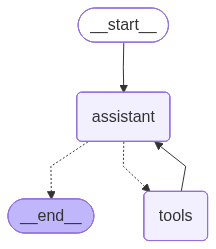

In [ ]:
# def build_agent():
from langgraph.graph.message import MessagesState

def create_builder():
    builder = StateGraph[MessagesState, None, MessagesState, MessagesState](MessagesState)
    builder.add_node("assistant", assistant)
    builder.add_node("tools", ToolNode(tools))
    builder.add_edge(START, "assistant")
    builder.add_conditional_edges("assistant", tools_condition)
    builder.add_edge("tools", "assistant")
    react_graph = builder.compile()
    display(Image(react_graph.get_graph(xray=True).draw_mermaid_png()))
    return react_graph

In [ ]:


# async def main():
dotenv.load_dotenv()
# react_graph = build_agent()
url = 'https://www.indeed.com/viewjob?jk=b1b396efd9d98573&from=shareddesktop_copy'

messages = [HumanMessage(content="""
Can you take a look at my resume at the location 'Aman_Saxena_02_12_2026.pdf' and these 3 job applications and tell me which one is the most suitable for my experience?

'https://www.indeed.com/viewjob?jk=40781386989fa311&from=shareddesktop_copy',
'https://www.indeed.com/viewjob?jk=ad7e3ed1af2823b4&from=shareddesktop_copy',
'https://www.indeed.com/viewjob?jk=348becd57110a790&from=shareddesktop_copy'

""")]

result = await react_graph.ainvoke({"messages": messages})
for m in result['messages']:
    m.pretty_print()
        

================================ Human Message =================================


Can you take a look at my resume at the location 'Aman_Saxena_02_12_2026.pdf' and these 3 job applications and tell me which one is the most suitable for my experience?

'https://www.indeed.com/viewjob?jk=40781386989fa311&from=shareddesktop_copy',
'https://www.indeed.com/viewjob?jk=ad7e3ed1af2823b4&from=shareddesktop_copy',
'https://www.indeed.com/viewjob?jk=348becd57110a790&from=shareddesktop_copy'


================================== Ai Message ==================================
Tool Calls:
  extract_resume_text (SOU8x320w)
 Call ID: SOU8x320w
  Args:
    file_path: Aman_Saxena_02_12_2026.pdf
  get_job_summary (ojLz1rCqK)
 Call ID: ojLz1rCqK
  Args:
    job_link: https://www.indeed.com/viewjob?jk=40781386989fa311&from=shareddesktop_copy
  get_job_summary (IJECTJfb5)
 Call ID: IJECTJfb5
  Args:
    job_link: https://www.indeed.com/viewjob?jk=ad7e3ed1af2823b4&from=shareddesktop_copy
  get_job_summary (oM

In [20]:
dotenv.load_dotenv()
main()

<coroutine object main at 0x1175ba5c0>